# Phase 2 — Exploratory Data Analysis
### Similar Songs AI — Music Recommendation Capstone

Roadmap:
1. Dataset overview
2. Genre distribution
3. Popularity by genre
4. Popularity distribution
5. Top artists
6. Audio feature analysis
7. Correlation analysis
8. Final EDA insights

**Dataset:** `cleaned_spotify_tracks.csv` — 113,999 tracks x 20 columns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/processed/cleaned_spotify_tracks.csv")
print(df.shape)
df.head()

(113999, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


---
## 1. Dataset Overview

Column types, nulls, and basic shape of the cleaned dataset coming out of Phase 1.


In [2]:
df.info()
print()
print("Nulls per column:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() else "None -- dataset is fully clean.")
print()
print("Duplicate track_id rows:", df['track_id'].duplicated().sum(),
      f"({df['track_id'].duplicated().mean():.1%}) -- same track tagged under multiple genres.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113999 entries, 0 to 113998
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  bool   
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           11

---
## 2. Genre Distribution

How many genres, and how balanced is representation across them.


Unique genres: 114
Tracks per genre -- min: 999, max: 1000, mean: 1000


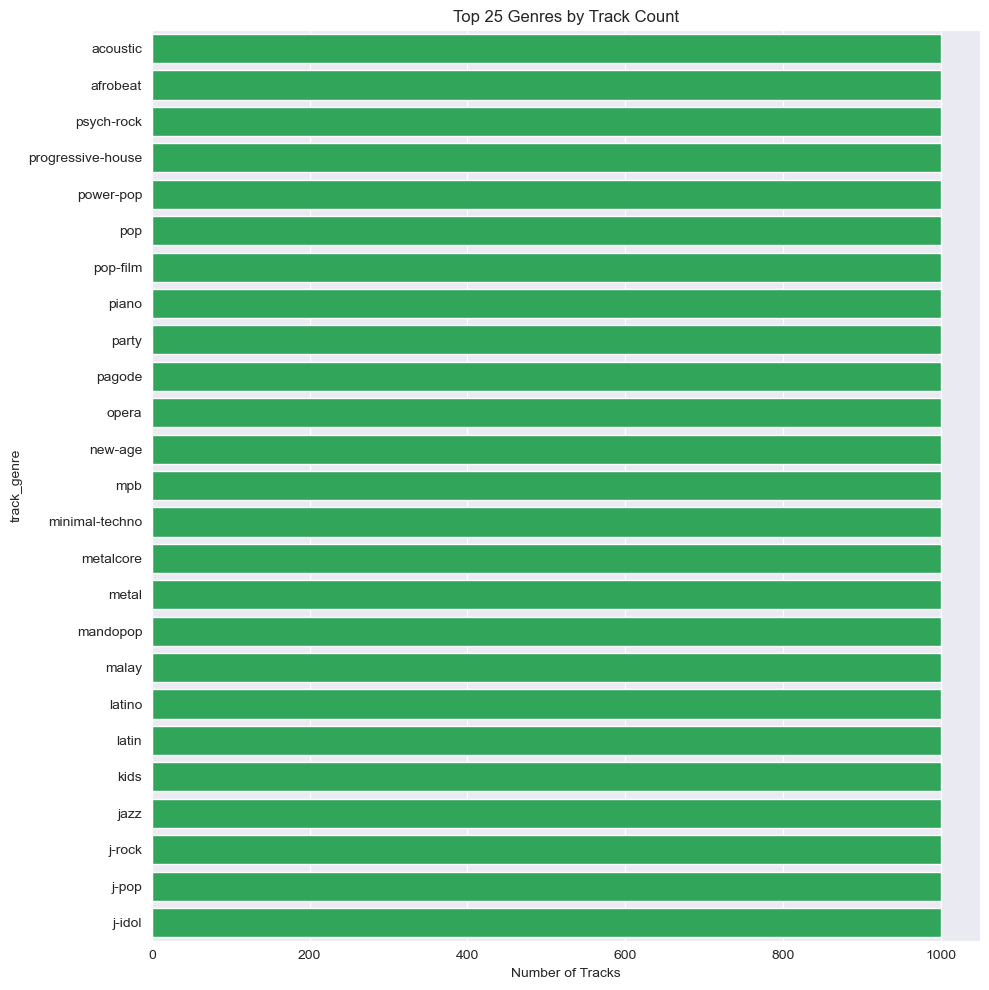

In [3]:
genre_counts = df['track_genre'].value_counts()
print(f"Unique genres: {df['track_genre'].nunique()}")
print(f"Tracks per genre -- min: {genre_counts.min()}, max: {genre_counts.max()}, mean: {genre_counts.mean():.0f}")

plt.figure(figsize=(10, 10))
sns.barplot(x=genre_counts.head(25).values, y=genre_counts.head(25).index, color='#1DB954')
plt.title('Top 25 Genres by Track Count')
plt.xlabel('Number of Tracks')
plt.tight_layout()
plt.show()

---
## 3. Popularity by Genre

Since genre representation is balanced (step 2), differences here reflect genuine popularity trends, not sample-size artifacts.


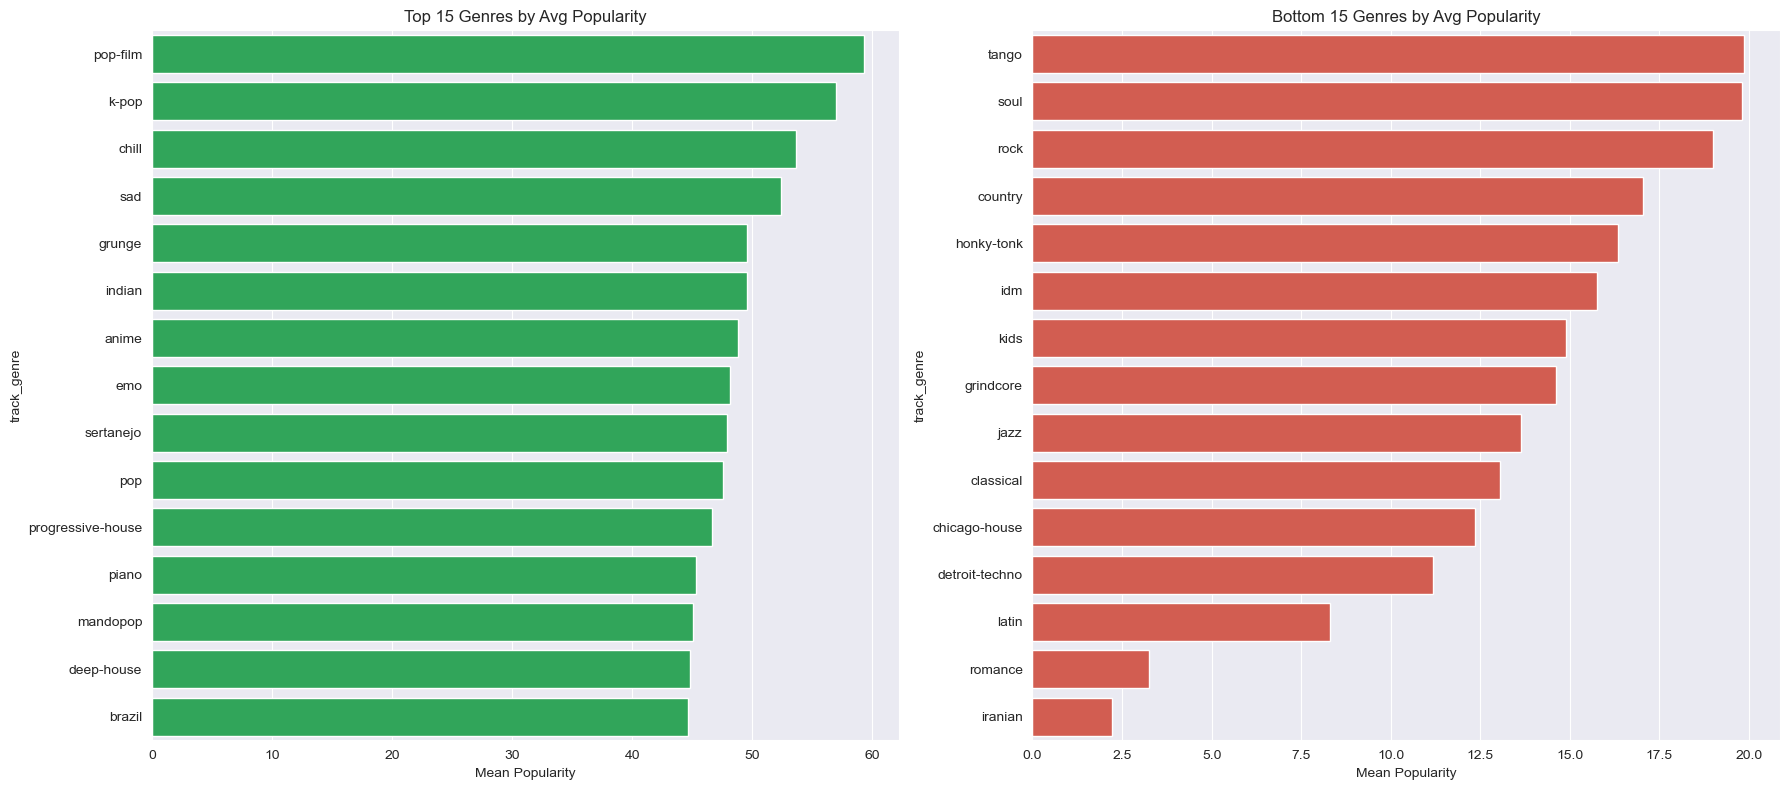

Most popular genre: pop-film (59.3)
Least popular genre: iranian (2.2)


In [4]:
genre_pop = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(x=genre_pop.head(15).values, y=genre_pop.head(15).index, ax=axes[0], color='#1DB954')
axes[0].set_title('Top 15 Genres by Avg Popularity')
axes[0].set_xlabel('Mean Popularity')

sns.barplot(x=genre_pop.tail(15).values, y=genre_pop.tail(15).index, ax=axes[1], color='#e74c3c')
axes[1].set_title('Bottom 15 Genres by Avg Popularity')
axes[1].set_xlabel('Mean Popularity')
plt.tight_layout()
plt.show()

print(f"Most popular genre: {genre_pop.idxmax()} ({genre_pop.max():.1f})")
print(f"Least popular genre: {genre_pop.idxmin()} ({genre_pop.min():.1f})")

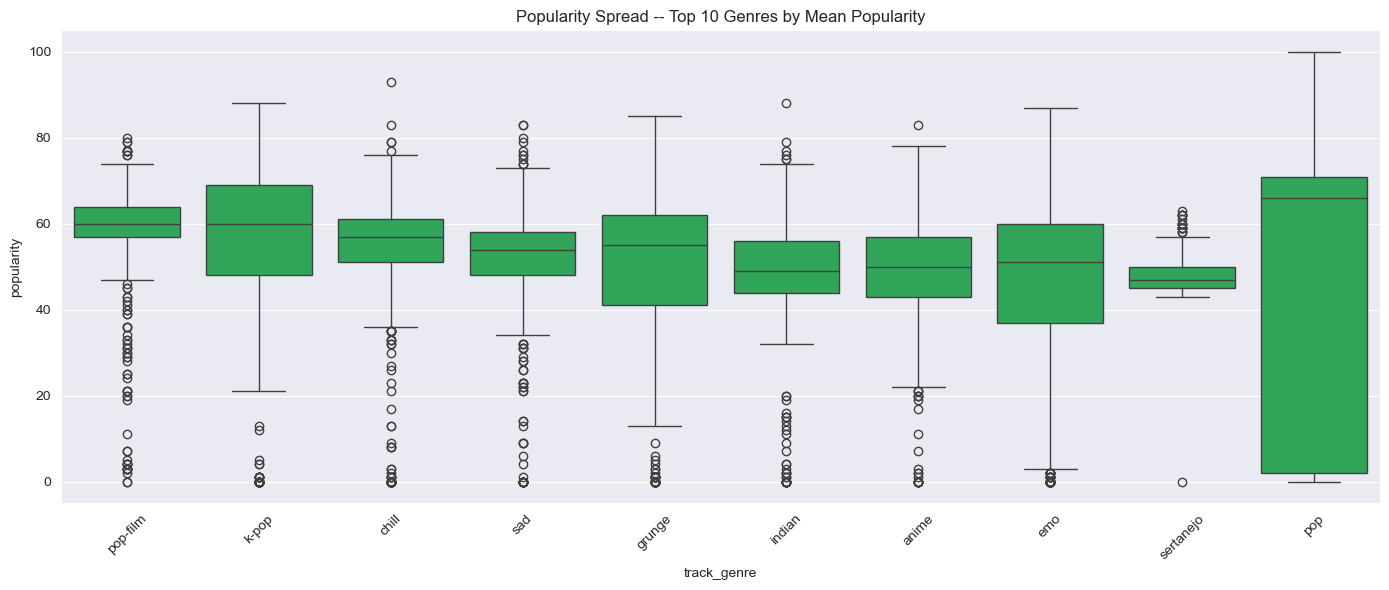

In [5]:
top_genres_by_pop = genre_pop.head(10).index.tolist()
subset = df[df['track_genre'].isin(top_genres_by_pop)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=subset, x='track_genre', y='popularity', order=top_genres_by_pop, color='#1DB954')
plt.title('Popularity Spread -- Top 10 Genres by Mean Popularity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 4. Popularity Distribution (Overall)

Now ignore genre entirely -- what does the popularity score look like across the whole dataset?


count    113999.000000
mean         33.238827
std          22.304959
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

Tracks with popularity == 0: 16019 (14.1%)


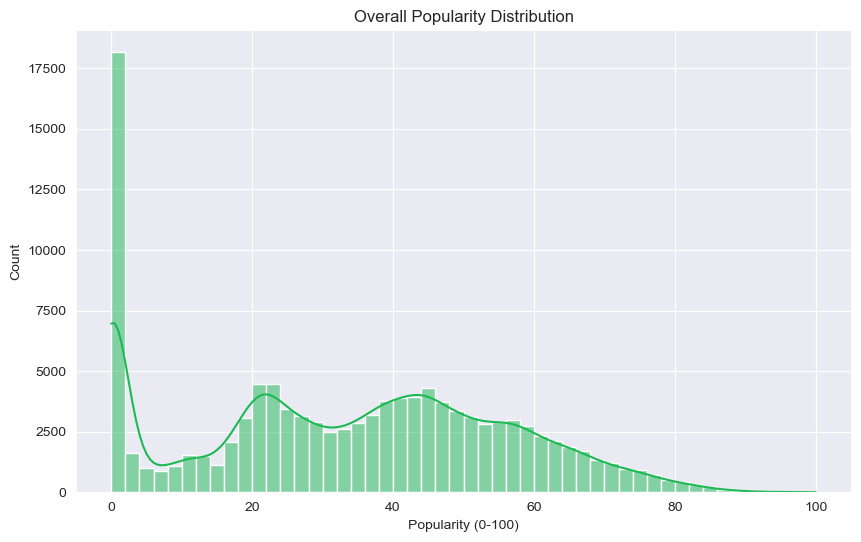

In [6]:
print(df['popularity'].describe())
print()
print("Tracks with popularity == 0:", (df['popularity']==0).sum(), f"({(df['popularity']==0).mean():.1%})")

plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], bins=50, kde=True, color='#1DB954')
plt.title('Overall Popularity Distribution')
plt.xlabel('Popularity (0-100)')
plt.show()

**Note:** a large spike at 0 is common in this dataset (new/unlisted tracks with no play data yet). Decide whether these should be treated as "genuinely unpopular" or "missing signal" -- this matters if popularity ever feeds into your similarity or ranking logic.


---
## 5. Top Artists

Two different questions: who appears most often (catalog size), and whose tracks are most popular on average (only counting artists with a reasonable number of tracks, so one hit song doesn't skew the ranking).


Top 15 artists by track count:
artists
The Beatles              279
George Jones             271
Stevie Wonder            236
Linkin Park              224
Ella Fitzgerald          222
Prateek Kuhad            217
Feid                     202
Chuck Berry              190
Håkan Hellström          183
OneRepublic              181
The Beach Boys           176
my little airport        171
Elvis Presley            169
Charlie Brown Jr.        169
Red Hot Chili Peppers    159
Name: count, dtype: int64


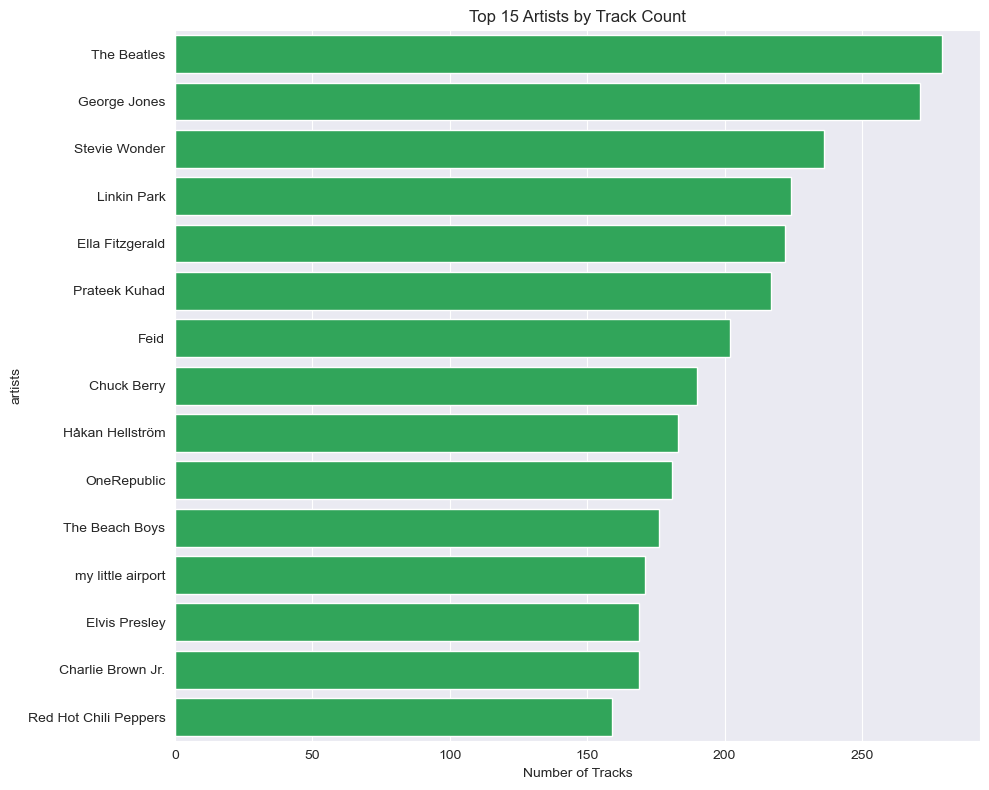

In [7]:
artist_counts = df['artists'].value_counts()
print("Top 15 artists by track count:")
print(artist_counts.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(x=artist_counts.head(15).values, y=artist_counts.head(15).index, color='#1DB954')
plt.title('Top 15 Artists by Track Count')
plt.xlabel('Number of Tracks')
plt.tight_layout()
plt.show()

Top 15 artists by avg popularity (min 5 tracks):
artists
Olivia Rodrigo               87.400000
Bad Bunny                    87.083333
Bad Bunny;Jhayco             87.000000
The Chainsmokers;Halsey      84.000000
Marshmello;Khalid            84.000000
Lil Nas X                    83.714286
Måneskin                     83.666667
One Direction                83.000000
TV Girl                      82.000000
Ariana Grande                81.454545
Eminem                       81.166667
The Chainsmokers;Coldplay    80.555556
Troye Sivan                  80.000000
Rels B                       79.833333
Beach Bunny                  79.428571
Name: popularity, dtype: float64


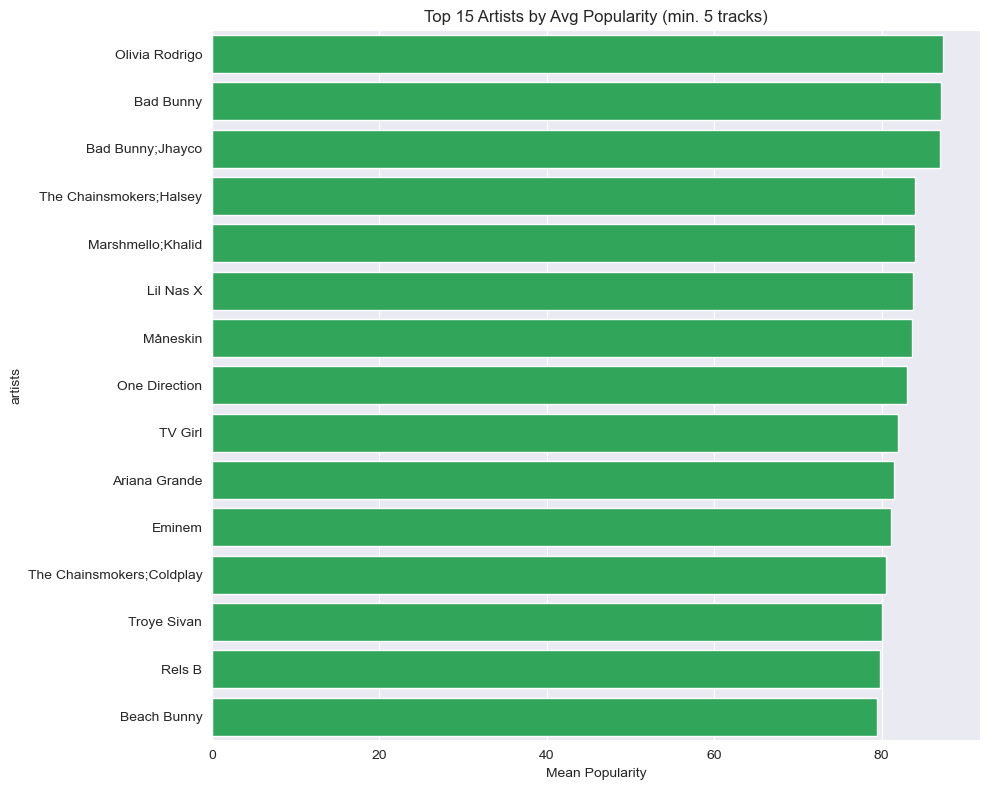

In [8]:
# Only artists with >= 5 tracks, to avoid one-hit-wonder noise
artist_pop = (df.groupby('artists')
                .filter(lambda x: len(x) >= 5)
                .groupby('artists')['popularity']
                .mean()
                .sort_values(ascending=False))

print("Top 15 artists by avg popularity (min 5 tracks):")
print(artist_pop.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(x=artist_pop.head(15).values, y=artist_pop.head(15).index, color='#1DB954')
plt.title('Top 15 Artists by Avg Popularity (min. 5 tracks)')
plt.xlabel('Mean Popularity')
plt.tight_layout()
plt.show()

---
## 6. Audio Feature Analysis

Distribution shape of each core audio feature -- tells you what needs scaling or transforming before Phase 3 (feature engineering) and Phase 4/5 (similarity modeling).


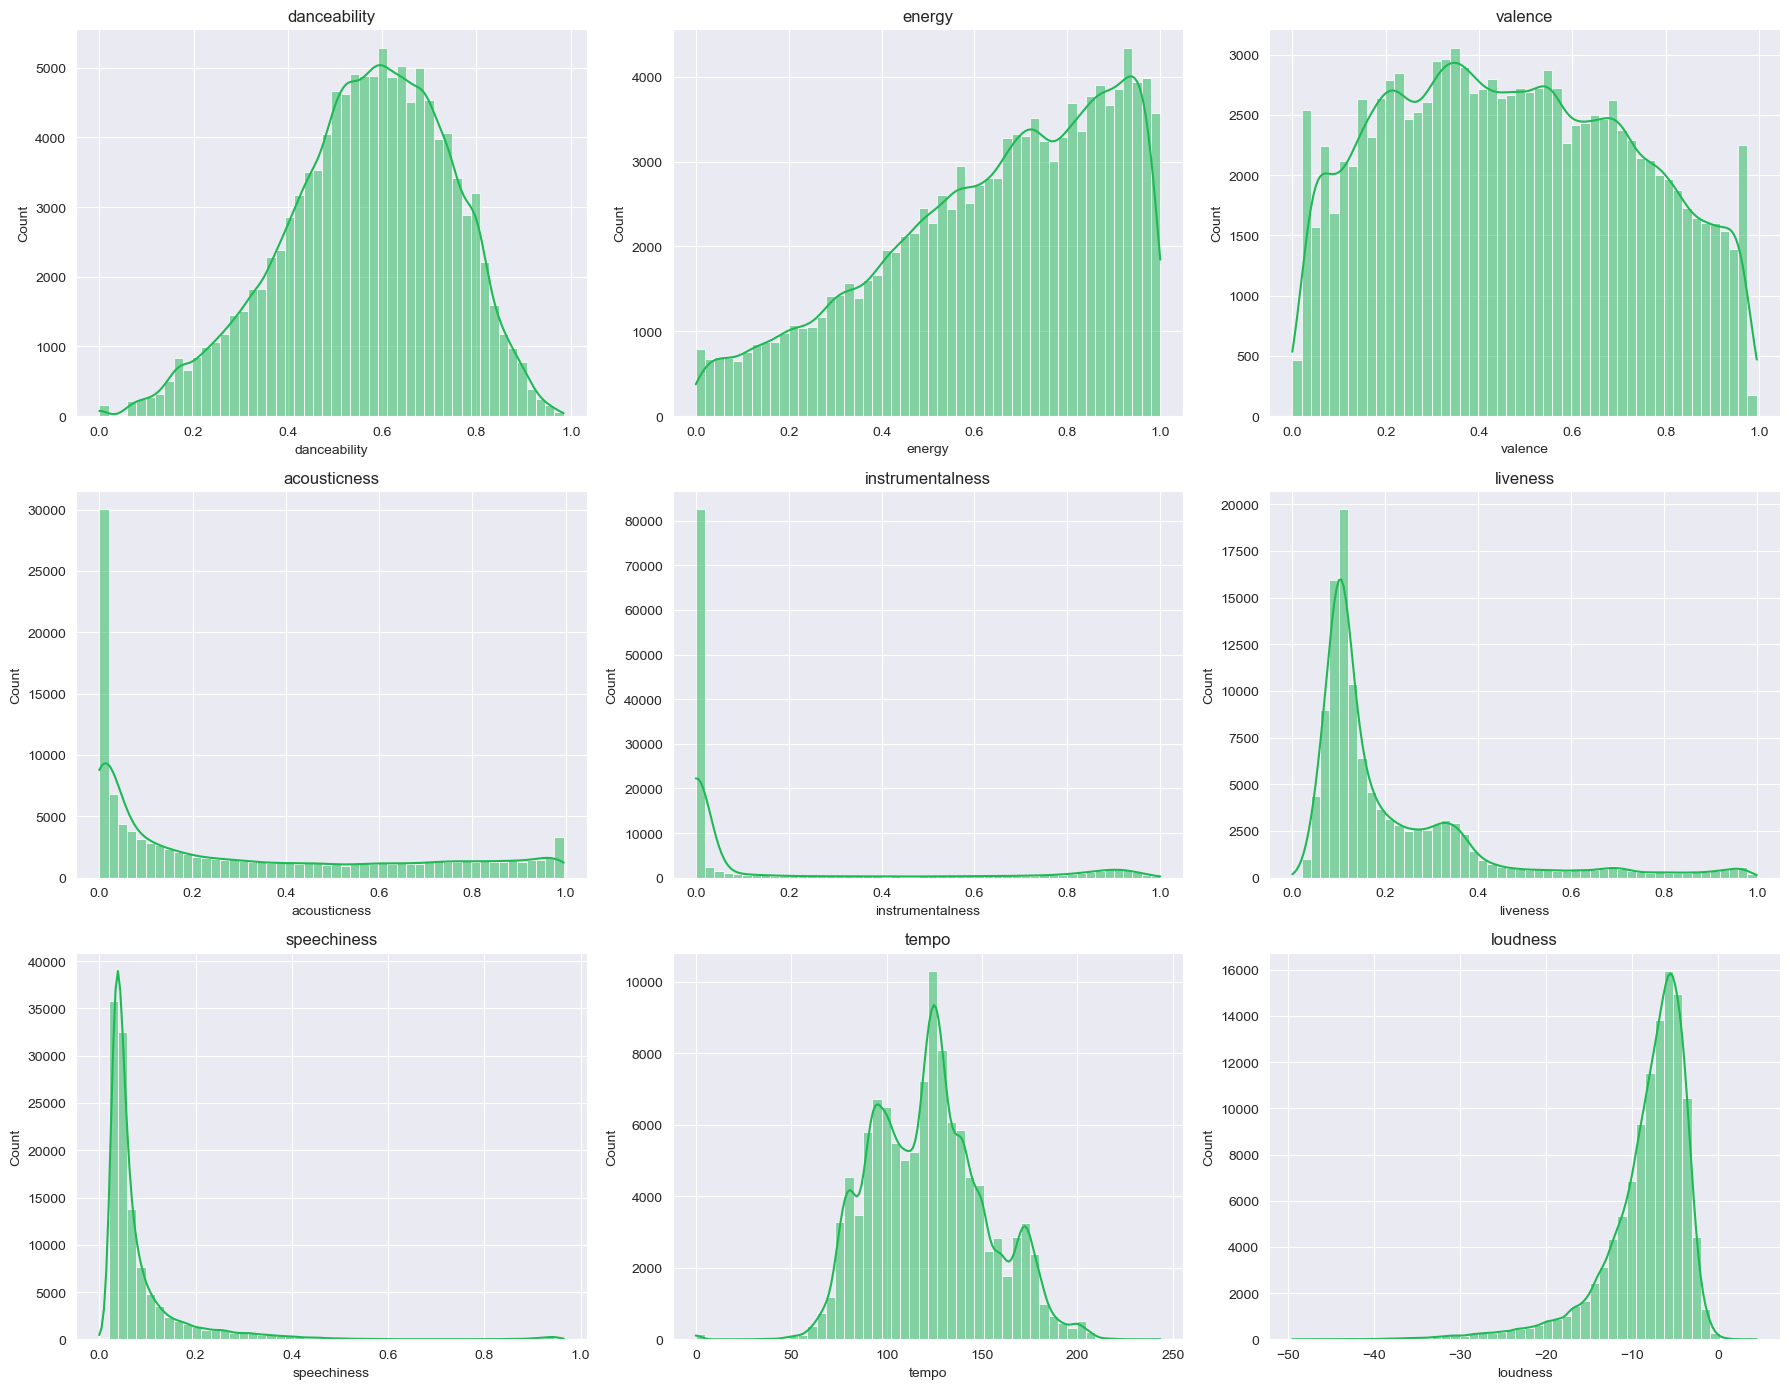

In [9]:
feature_cols = ['danceability','energy','valence','acousticness','instrumentalness',
                'liveness','speechiness','tempo','loudness']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.histplot(df[col], bins=50, kde=True, ax=ax, color='#1DB954')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [10]:
df[feature_cols + ['popularity','duration_ms']].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,113999.0,0.566801,0.173543,0.000,0.4560,0.580000,0.6950,0.985
energy,113999.0,0.641383,0.251530,0.000,0.4720,0.685000,0.8540,1.000
valence,113999.0,0.474066,0.259261,0.000,0.2600,0.464000,0.6830,0.995
acousticness,113999.0,0.314907,0.332522,0.000,0.0169,0.169000,0.5975,0.996
instrumentalness,113999.0,0.156051,0.309556,0.000,0.0000,0.000042,0.0490,1.000
liveness,113999.0,0.213554,0.190378,0.000,0.0980,0.132000,0.2730,1.000
speechiness,113999.0,0.084652,0.105733,0.000,0.0359,0.048900,0.0845,0.965
tempo,113999.0,122.147695,29.978290,0.000,99.2185,122.017000,140.0710,243.372
loudness,113999.0,-8.258950,5.029357,-49.531,-10.0130,-7.004000,-5.0030,4.532
popularity,113999.0,33.238827,22.304959,0.000,17.0000,35.000000,50.0000,100.000


**Things to note:** `acousticness`, `instrumentalness`, and `speechiness` are heavily right-skewed (most songs near 0). `tempo`, `loudness`, and `duration_ms` are on completely different scales than the [0,1]-bounded features -- all of this needs normalizing before any distance-based similarity calculation.


---
## 7. Correlation Analysis

Which audio features move together. Highly correlated features (|r| > ~0.6-0.7) effectively double-count the same underlying signal in a similarity score.


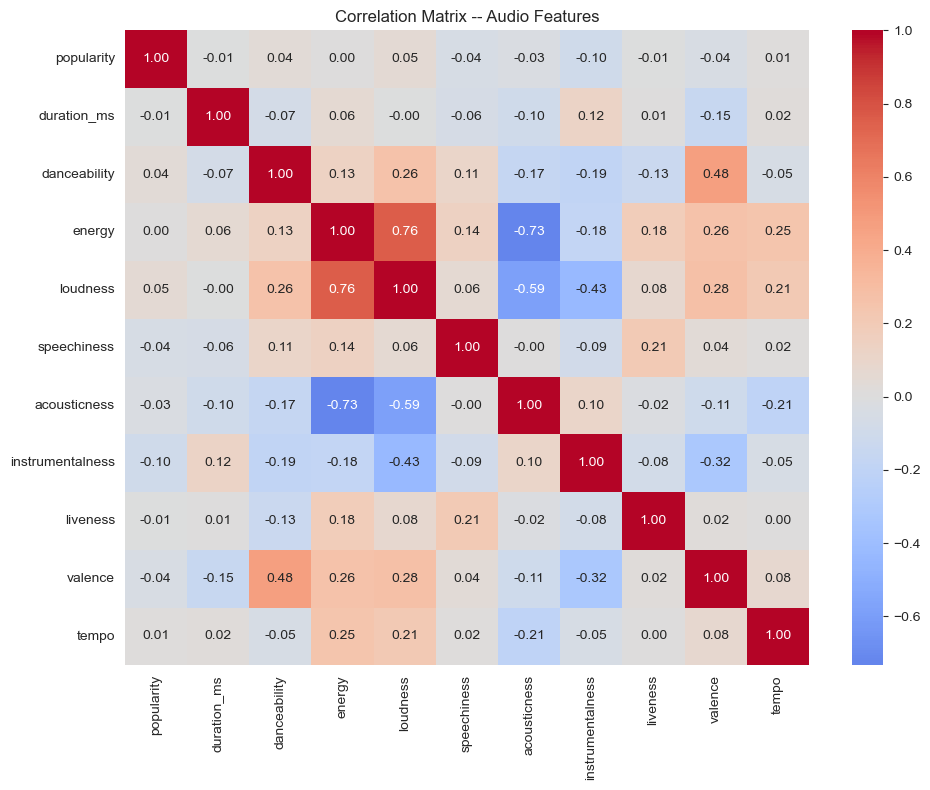

Feature pairs with |correlation| > 0.5:
energy    loudness        0.761690
          acousticness   -0.733908
loudness  acousticness   -0.589804
dtype: float64


In [11]:
numeric_feats = ['popularity','duration_ms','danceability','energy','loudness',
                  'speechiness','acousticness','instrumentalness','liveness','valence','tempo']
corr = df[numeric_feats].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix -- Audio Features')
plt.tight_layout()
plt.show()

high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("Feature pairs with |correlation| > 0.5:")
print(high_corr[high_corr.abs() > 0.5].sort_values(key=abs, ascending=False))

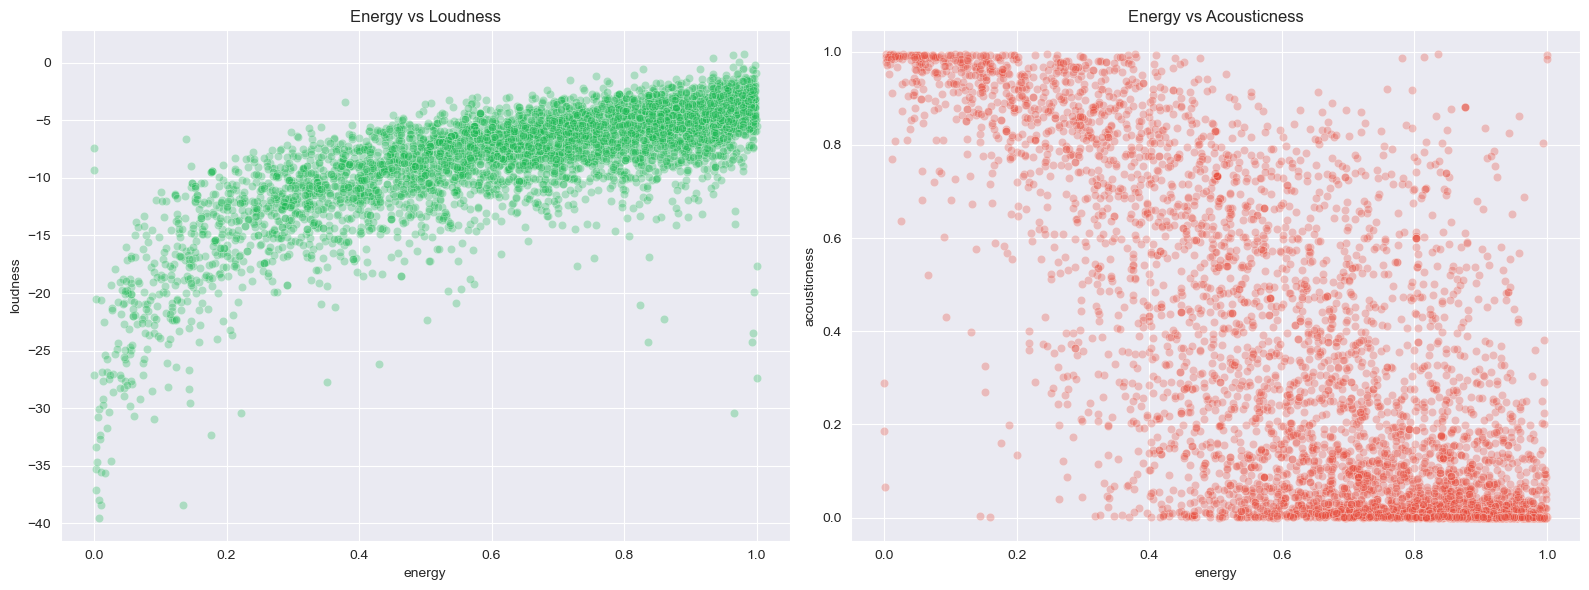

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df.sample(5000, random_state=42), x='energy', y='loudness',
                 alpha=0.3, color='#1DB954', ax=axes[0])
axes[0].set_title('Energy vs Loudness')

sns.scatterplot(data=df.sample(5000, random_state=42), x='energy', y='acousticness',
                 alpha=0.3, color='#e74c3c', ax=axes[1])
axes[1].set_title('Energy vs Acousticness')
plt.tight_layout()
plt.show()

---
## 8. Final EDA Insights

Summary of what this phase found, and the concrete decisions it feeds into Phase 3 (feature engineering).

**Findings:**
- Genres are perfectly balanced (~1000 tracks each, 114 genres) -- differences in popularity by genre are real signal, not sampling bias.
- Popularity is right-skewed with a large spike at 0 (~14% of tracks) -- likely tracks with no/low listening data rather than confirmed unpopularity.
- A small number of artists dominate track count (The Beatles, George Jones, Stevie Wonder), but the most *popular* artists on average are different (Olivia Rodrigo, Bad Bunny) -- catalog size and popularity are separate signals.
- Several audio features are heavily skewed (acousticness, instrumentalness, speechiness) and on very different scales than others (tempo, loudness, duration_ms) -- normalization is mandatory before similarity modeling.
- `energy` correlates strongly with `loudness` (+) and `acousticness` (-) -- redundant signal that should be addressed (drop one, combine, or use PCA) rather than fed in raw.
- ~24k tracks are duplicated across genre labels -- a deduplication strategy is needed so a track doesn't end up matching itself under a different genre tag.

**Decisions to carry into Phase 3:**
- [ ] Deduplication strategy for repeated `track_id`s across genres
- [ ] Scaling/normalization approach for all numeric features
- [ ] How to handle the energy/loudness/acousticness redundancy
- [ ] Whether/how popularity feeds into the similarity model vs. used only for display/filtering
- [ ] Whether genre is a similarity feature, a filter, or excluded
- [ ] Final feature list going into Phase 3
